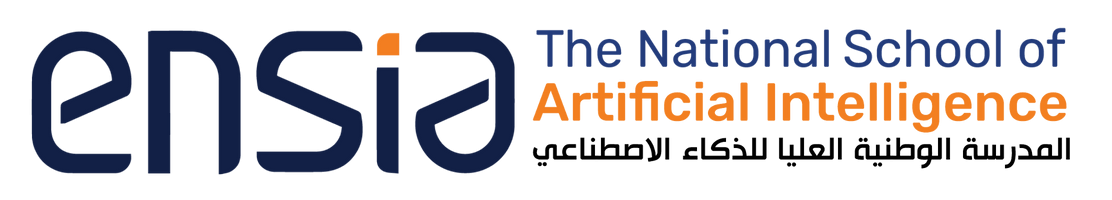

# **PROBABILITY BASED LEARNING___Part I: NAIVE BAYES**

# **Overview**
>Probability-based learning methods rely on the principles of probability theory to make predictions based on the **likelihood** of different outcomes. These models assume that the features of the data contribute **probabilistically** to the prediction of the target variable. One of the most widely used probability-based learning algorithms is the ***Naive Bayes Classifier***, known for its simplicity, efficiency, and effectiveness, especially with high-dimensional data.

> This lab notebook focuses on implementing and understanding two types of Naive Bayes classifiers:

1. Categorical Naive Bayes (CNB):
  - Designed for categorical features.
  - Estimates class-conditional probabilities based on the frequency of feature values in the training data.
  - Suitable for datasets with discrete variables.

2. Gaussian Naive Bayes (GNB):
  - Assumes that continuous features follow a Gaussian (normal) distribution.
  - Calculates class-conditional probabilities using the probability density function of the normal distribution.
  - Useful for datasets where features are continuous and approximately normally distributed.

3. Additionally, this notebook explores techniques for handling mixed-type features by combining the GNB and CNB approaches into a hybrid classifier. This classifier can be constructed using two different approaches:
  - **Direct Modeling**: Continuous features are modeled using Gaussian distributions, while categorical features are handled using frequency-based probabilities.
  - **Discretization Approach**: Continuous features are first transformed using equal-frequency binning, converting them into categorical features that can be processed using frequency-based probabilities.

## **Objectives**
By working through this notebook, you will gain practical insights into:

  - ✅ Calculating prior and likelihood probabilities.
  - ✅ Handling continuous and categorical data.
  - ✅ Implementing and validating Naive Bayes classifiers from scratch.

This hands-on approach will strengthen your understanding of probability-based models and their applications in real-world classification tasks. 🚀



---
# **PART I: Naive Bayes**
---

***Naive bayes***: is a supervied machine leaarning algorithm  that is used for classification tasks such as text classification. They use principles of probability to perform classification tasks.

Naïve Bayes is part of a family of generative learning algorithms, meaning that it seeks to model the distribution of inputs of a given class or category

Bayes’ Theorem is distinguished by its use of sequential events, where additional information later acquired impacts the initial probability. These probabilities are denoted as the prior probability and the posterior probability. The prior probability is the initial probability of an event before it is contextualized under a certain condition, or the marginal probability. The posterior probability is the probability of an event after observing a piece of data.

Naive Bayes classifier assumes that the effect of a particular feature in a class is independent of other features; the features are indepedent, this is what earned him the title of 'naive'.

**HOW NAIVE BAYES WORKS:**
Naive Bayes classifier calculates the probability of an event in the following steps:

  * **Step 1:**  Calculate the prior probability for given class labels
  * **Step 2:**  Find Likelihood probability with each attribute for each class
  * **Step 3:**  Put these value in Bayes Formula and calculate posterior probability.
  * **Step 4:**  Assign the class with the highest posterior probability to the input.
  

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/1*VGAoUgY28wygHsD-FXH4mg.jpeg" width="50%">


Naive Bayes Classifier formula can be written based on Bayes theorem as:

> $P(y \mid x_1, \ldots,x_j) = \frac{P(x_1,\ldots ,x_j \hspace{0.2cm} \mid \hspace{0.2cm} y) \hspace{0.2cm} P(y)}{P(x_1,\ldots,x_j)}$

Where,

- **$x_1,\ldots, x_j$** are j features that are independent of each other. y is the dependent variable.
- **$P(y \mid x_1,\ldots, x_j)$:** Posterior Probability
- **$P(x_1, \ldots, x_j \mid y)$:** Likelihood of features x1 to xj given that their class is y.
- **$P(y)$:** Prior Probability
- **$P(x_1,\ldots, x_j)$:** Marginal Probability

## **Implementation**

Before we jump into the main Naive bayes classes, let us first define some utility functions that we might need in some part of the upcoming sections

In [129]:
import numpy as np
import pandas as pd
import matplotlib as plt

from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.model_selection import train_test_split

## Utility Functions

> `accuracy_score`

In [130]:
def accuracy_score(y_true, y_pred):

	"""	score = (y_true - y_pred) / len(y_true) """

	return round(float(sum(y_pred == y_true))/float(len(y_true)) * 100 ,2)

---
## **1. NAIVE BAYES WITH DISCRETE FEATURES**
---
First let's try to implement the naive bayes with discrete features.

We will be using the Tennis Play dataset for training. This dataset includes **features [Outlook, Temperature, Humidity, Windy]**, and the corresponding **target** variable **'Play'** that corresponds to whether tennis is playable or not.

We need to predict whether players will play or not based on given weather conditions.

***
**Note**: For this first Variant of Naive Bayes Classifier, we will decompose the class methods into into smaller functions to simplify and clarify the workflow. After in a separate cell, we will merge everything in one single Class.
***

### Loading the data

In [131]:
df = pd.read_csv('nb_data.csv')
y = df['Play'] #TODO: assign the target variable to Y
X = df[['Outlook', 'Temperature Nominal', 'Humidity Nominal', 'Windy']] #TODO: Drop the numerical features and keep the categorical ones.

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training (Fitting) the model

The fit method estimates class priors and conditional probabilities for each feature value given a class, enabling the Naive Bayes Classifier to model the data distribution for prediction. It involves The first Two steps.

###  **Step 1:**  Calculate the prior probability for given class labels


First, we get the number of classes we have and the count of each class to detrimine the prior probabilities ($P(Y)$)

In [133]:
classes = []
priors = {}
classes , counts = np.unique(y, return_counts=True) # TODO: Find the unique class labels in y and count their occurrences
probabilities = counts / len(y) # TODO: Compute the prior probability of each class (P(y) = count of class samples / total samples)
priors = dict(zip(classes, probabilities)) # TODO: Store the prior probabilities in a dictionary mapping each class to its prior

print(f"the target classes are {classes}")
print(f'the prior probabilities are {priors}')

the target classes are ['no' 'yes']
the prior probabilities are {'no': np.float64(0.39285714285714285), 'yes': np.float64(0.6071428571428571)}


### **Step 2:** Find Likelihood probability with each attribute for each class

***How to compute the likelihoods ($P(x_1,\ldots ,x_j \hspace{0.2cm} \mid \hspace{0.2cm} y)$)💡:**
- Start by iterating through each target class and filtering the dataset to create a subset called **conditional_class**.
- Next, for each feature (attribute), calculate the likelihoods using the filtered data, referred to as **conditional_attr**, and store these values in our likelihood dictionary.

In [134]:
attributes= []
n_attributes = []
likelihoods = {}

attributes = X.columns.tolist() #TODO: Get the list of feature (attribute) names from the dataset
n_attributes = len(attributes) # TODO: Store the number of attributes (features) in the dataset

# Loop over each class to compute likelihood probabilities
for class_ in classes:
    likelihoods[class_] = {} # Initialize an empty dictionary for this class
    conditional_class = df[df['Play'] == class_] # TODO: Filter the dataset to only include samples belonging to the current class
    conditional_size = len(conditional_class)  # TODO: Get the number of samples for this class

# Loop over each attribute to compute conditional probabilities
    for attr in attributes:
        conditional_attr = conditional_class.loc[: , attr]
        values , counts = np.unique(conditional_attr , return_counts = True)
        likelihoods[class_][attr] = dict(zip(values, counts / conditional_size))
likelihoods

{'no': {'Outlook': {'overcast': np.float64(0.09090909090909091),
   'rainy': np.float64(0.36363636363636365),
   'sunny': np.float64(0.5454545454545454)},
  'Temperature Nominal': {'cool': np.float64(0.18181818181818182),
   'hot': np.float64(0.5454545454545454),
   'mild': np.float64(0.2727272727272727)},
  'Humidity Nominal': {'high': np.float64(0.8181818181818182),
   'normal': np.float64(0.18181818181818182)},
  'Windy': {np.False_: np.float64(0.36363636363636365),
   np.True_: np.float64(0.6363636363636364)}},
 'yes': {'Outlook': {'overcast': np.float64(0.4117647058823529),
   'rainy': np.float64(0.35294117647058826),
   'sunny': np.float64(0.23529411764705882)},
  'Temperature Nominal': {'cool': np.float64(0.35294117647058826),
   'hot': np.float64(0.17647058823529413),
   'mild': np.float64(0.47058823529411764)},
  'Humidity Nominal': {'high': np.float64(0.29411764705882354),
   'normal': np.float64(0.7058823529411765)},
  'Windy': {np.False_: np.float64(0.6470588235294118),
   

---
Now that we finished with Fitting the model, Let us explore how predictions are computed.
---

## Make Prediction (Predict)

> The predict method computes the posterior probability of each class for given instances using learned priors and likelihoods, returning the class with the highest probability. It invovles the third and forth steps,  

>Naive Bayes classifiers typically ***ignore the P(X)*** term (the denominator) when making predictions. This simplification is theoretically suboptimal but often leads to reasonable performance in practice.

> A naive Bayes model returns a **maximum a posteriori** (**MAP**) **prediction** where the posterior probabilities for the levels of the target feature are computed under the assumption of ***conditional independence*** between the descriptive features in an instance given a target feature level.

> Conditional independence between features allows  to **factorize** the *joint distribution*, and this helps with the ***curse of dimensionality problem*** by reducing the number of probabilities we are required to calculate from the data as well as the number of conditioning constraints on these probabilities



> $Class(q) =\overset{\small \textbf{argMax}}{\scriptsize _\text{c ∈ classes}} (\prod_{i=1}^{n} P(q_i \mid c)) \hspace{0.2cm} \text{x} \hspace{0.2cm} P(c) $


### **Step 3:** Put these value in Bayes Formula and calculate posterior probability.

> Fist, we get an unseen instance from the X_test set. So given the feature values ($x_1,\ldots,x_j$), we will try to predict whether or not we wil play tennis.

In [135]:
x = X_test.iloc[0 , :]
print(x)

Outlook                sunny
Temperature Nominal      hot
Humidity Nominal        high
Windy                  False
Name: 9, dtype: object


Then, we an empty dictionary where we store the probabilites of each class

In [136]:
predictions = {key : None for key in classes }
predictions

{'no': None, 'yes': None}

Everything is ready, Now we apply the formulas by multiplying the **likelihoods** by the **prior probabilities** to calculate the probability for each class.

In [137]:
# Loop over each class to compute the final probability
for class_ in classes:
    to_multiply = np.zeros(len(x) + 1) # TODO: Initialize an array to store likelihood values for each feature + 1 element to store the prior probability

# TODO: Loop over each attribute and retrieve the corresponding likelihood probability
    for i, attr in enumerate(attributes):
        value = x[attr]  # Get the value of the attribute for the given sample
        to_multiply[i] = likelihoods[class_][attr][value] # TODO: Retrieve likelihood P(x | class)

    to_multiply[-1] = priors[class_]  # TODO: Store the prior probability in the last position of the array
    predictions[class_] = np.multiply.reduce(to_multiply) # Multiply all the likelihoods with the prior to get the final class probability

### **Step 4:** Assign the class with the highest posterior probability to the input.

In [138]:
print(predictions)
final_class = max(predictions, key=predictions.get)  # Select the class with the highest probability
final_class

{'no': np.float64(0.034775142213158736), 'yes': np.float64(0.004797766857608095)}


'no'

---
> For this instance, we notice that naive bayes predicted **NO** as a Play class(It has higher score then 'Yes' Class).
---

## Now let's merge everything to a single class AND create our naive bayes classifier

In [139]:
class NaiveBayesClassifier:
    def __init__(self):
        self.priors = {}
        self.likelihoods = {}
        self.classes = []
        self.attributes = []

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        #-------------------------------------------------------------------------------------------------------
        #-------------------Step 1: Calculate Prior Probs ------------------------------------------------------
        #-------------------------------------------------------------------------------------------------------
        # Check that X is a DataFrame and y is array-like with matching number of samples.
        assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame."
        assert hasattr(y, '__len__'), "y must be array-like."
        assert len(X) == len(y), "X and y must have the same number of samples."

        self.classes, counts = np.unique(y, return_counts=True)  # TODO: Extract unique class labels and their counts from y
        probabilities = counts / len(y)  # TODO: Compute the prior probability for each class
        self.priors = dict(zip(self.classes, probabilities))  # TODO: Store the prior probabilities in a dictionary
        self.attributes = X.columns.tolist()  # TODO: Store the attribute (feature) names in a list for later use

        # Ensure there is at least one attribute.
        assert len(self.attributes) > 0, "X must have at least one feature."

        """
        Likelihoods:
        {
            class: {
                attr: {
                    val: proba,
                    ...
                },
                ...
            },
            ...
        }
        """
        #-------------------------------------------------------------------------------------------------------
        #-------------------Step 2: Calculate Likelihoods for each class----------------------------------------
        #-------------------------------------------------------------------------------------------------------
        for class_ in self.classes:
            self.likelihoods[class_] = {} # Initialize a dictionary to store likelihoods for this class
            conditional_distribution = X[y == class_] # TODO: Extract all rows where the target label is the current class

            # Ensure there is at least one sample for this class.
            assert len(conditional_distribution) > 0, f"No samples found for class {class_}."

            total = len(conditional_distribution) # TODO: Store the total number of samples for this class

            for attr in self.attributes:
                # Check that the attribute exists.
                assert attr in conditional_distribution.columns, f"Attribute {attr} missing in X."

                conditional_attr = conditional_distribution[attr] # TODO: Extract values of the attribute for the current class
                all_values = np.unique(X[attr])  # Get all unique values for this attribute in the entire dataset
                V = len(all_values)  # Number of distinct values for this feature
                smoothed = {}
                for val in all_values:
                    count = np.sum(conditional_attr == val)  # Count occurrences in the current class
                    smoothed[val] = (count + 1) / (total + V)  # Apply Laplace smoothing with alpha=1
                self.likelihoods[class_][attr] = smoothed  # Store smoothed likelihoods

    def predict(self, X):
        # If X is a DataFrame, check that all required attributes are present.
        if isinstance(X, pd.DataFrame):
            for attr in self.attributes:
                assert attr in X.columns, f"Missing attribute: {attr}"
            X = X[self.attributes].to_numpy()
        else:
            # Otherwise, assume X is a NumPy array and validate its dimensions.
            assert isinstance(X, np.ndarray), "X must be a pandas DataFrame or a numpy array."
            assert X.ndim == 2, "X must be a 2D array."
            assert X.shape[1] == len(self.attributes), "Mismatch in number of features between X and training data."
        return np.apply_along_axis(self.__predict, axis=1, arr=X)

    def __predict(self, x):
        #--------------------------------------------------------------------------------------------------------
        #-------------------Step 3: Apply the formulas (MAP) ----------------------------------------------------
        #--------------------------------------------------------------------------------------------------------
        # Ensure the input vector length matches the number of attributes.
        assert len(x) == len(self.attributes), "Input vector length does not match number of attributes."


        predictions = {class_: None for class_ in self.classes}

        for class_ in self.classes:
            to_multiply = np.zeros(len(self.attributes) + 1) # TODO: Initialize an array to store likelihood values for each feature and prior probability.
            for i, attr in enumerate(self.attributes):
                value = x[i] # The current feature value.

                # Check that the likelihood for the attribute exists.
                assert attr in self.likelihoods[class_], f"Likelihood for attribute {attr} not found in class {class_}."

                # Use get() to handle unseen values; fall back to smoothed default if available
                to_multiply[i] = self.likelihoods[class_][attr].get(value,
                    self.likelihoods[class_][attr].get('__unseen__', 0))

            # Set the last element to the class prior.
            assert class_ in self.priors, f"Prior for class {class_} not found."
            to_multiply[-1] = self.priors[class_]

            predictions[class_] = np.multiply.reduce(to_multiply)

        # Return the class with the highest posterior probability.
        return max(predictions, key=predictions.get)

In [140]:
clf = NaiveBayesClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)
score = accuracy_score(y_pred, y_train)
print(f"The predicted classes: {y_pred}")
print(f"With an accuracy of: {score}%")

The predicted classes: ['yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'no' 'no' 'yes' 'no' 'yes' 'no' 'yes' 'no' 'yes']
With an accuracy of: 86.36%


---
> The Naive Bayes Classifier is ready!, Let's test it against Scikit-Learn's Categorical Naive Bayes classifier
---

In [141]:
# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Some Encoding (for the SKlearn Classifier)---------------------------
#-----------------------------------------------------------------------------------------------------------
for col in X.columns:
    X[col] = X[col].astype('category').cat.codes
# Convert target to numeric codes as well
y = y.astype('category').cat.codes
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Our Categorical Naive Bayes classifier-------------------------------
#-----------------------------------------------------------------------------------------------------------

clf = NaiveBayesClassifier()
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------scikit-learn Categorical Naive Bayes classifier----------------------
#-----------------------------------------------------------------------------------------------------------

gnb = CategoricalNB()
gnb.fit(X_tr, y_tr)
y_pred_sklearn = gnb.predict(X_te)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Compare the results--------------------------------------------------
#-----------------------------------------------------------------------------------------------------------
print("Custom Categorical Naive Bayes predictions:", y_pred)
print("Scikit-learn Categorical Naive Bayes predictions:", y_pred_sklearn)

assert np.array_equal(y_pred, y_pred_sklearn), "The predictions do not match!"
print("Test passed successfully! =D, Congratulatiosn, your Classifier is working as expected.")

Custom Categorical Naive Bayes predictions: [0 1 1 1 1 1]
Scikit-learn Categorical Naive Bayes predictions: [0 1 1 1 1 1]
Test passed successfully! =D, Congratulatiosn, your Classifier is working as expected.


/tmp/ipykernel_33706/1937282749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category').cat.codes
/tmp/ipykernel_33706/1937282749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category').cat.codes
/tmp/ipykernel_33706/1937282749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

---
## **2. NAIVE BAYES WITH CONTINUOUS FEATURES(GAUSSIAN NAIVE BAYES)**
---

>In the previous dataset, we had to drop continuous features to apply the Categorical Naive Bayes classifier. However, in real-world applications, this is rarely the best approach for classification problems. So, how can we effectively handle continuous features?

> In this section, we explore two common approaches:

> - ***Binning:*** A straightforward method that discretizes continuous features into bins, allowing them to be used with Categorical Naive Bayes.
- ***Probability Density Functions:*** A more robust approach that models continuous features using a probability distribution, enabling the computation of likelihoods directly.

### **2.1 Binning**

> First we load the same dataset, but this time we include all features

In [142]:
X = df.drop(['Play'], axis=1)
y = df['Play']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#### Extra Utility Functions

We need to define some utility functions that will assist in descritisizing our continuous features

> `equal_frequency_binning_fit`

In [143]:
def is_continuous(series):
    """
    Check if a pandas Series contains continuous (numeric) data.

    Parameters:
        series (pd.Series): Input Series to check.

    Returns:
        bool: True if the series is numeric, False otherwise.
    """
    return pd.api.types.is_numeric_dtype(series)


def equal_frequency_binning_fit(df, n_bins=4):
    """
    Fit equal-frequency binning on the DataFrame and return the bin edges for each numeric column.

    Parameters:
        df (pd.DataFrame): Input DataFrame with features.
        n_bins (int): Number of bins.

    Returns:
        dict: Dictionary mapping column names to bin edges.
    """
    bin_edges = {}
    for col in df.columns:
        if is_continuous(df[col]):
            # Compute quantiles and use them as bin edges
            quantiles = np.linspace(0, 100, n_bins + 1)
            edges = np.percentile(df[col].dropna(), quantiles)
            bin_edges[col] = edges
    return bin_edges

> `equal_frequency_binning_transform`

In [144]:
def equal_frequency_binning_transform(df, bin_edges):
    """
    Apply equal-frequency binning to the DataFrame using the provided bin edges.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        bin_edges (dict): Dictionary mapping column names to bin edges.

    Returns:
        pd.DataFrame: Transformed DataFrame with binned values as strings.
    """
    binned_df = df.copy()
    for col, edges in bin_edges.items():
        n_bins = len(edges) - 1
        labels = [f"bin{i+1}" for i in range(n_bins)]
        # Use pd.cut with fixed bin edges.
        # Setting include_lowest=True ensures the smallest value is included in the first bin.
        binned_df[col] = pd.cut(binned_df[col], bins=edges, include_lowest=True, labels=labels).astype(str)
    return binned_df

---
#### Discretizing continuous features (Binning)

> The first step in binning (equal frequency binning) is define foreach feature the bins boundaries or edges that defines each bin. Then the second step consists of using the boundaries to assign bins to instances according to their features values.

**Question:** Why do need the first step ? why not just assigning bins to instances without defining and storing boundaries ?

In [145]:
#-----------------------------Step 1-------------------------------------------

binning_boundaries = {attr: np.linspace(X_train[attr].min(), X_train[attr].max(), num=5) for attr in X_train.columns if is_continuous(X_train[attr])}
#-----------------------------Step 2-------------------------------------------
X_train_binned = X_train.copy()
for attr, boundaries in binning_boundaries.items():
    X_train_binned[attr] = np.digitize(X_train[attr], bins=boundaries)
X_train_binned

,Outlook,Temperature Numeric,Temperature Nominal,Humidity Numeric,Humidity Nominal,Windy
17,rainy,3,mild,2,normal,1
22,sunny,1,cool,1,normal,1
11,sunny,2,mild,4,high,1
13,sunny,3,mild,1,normal,5
15,rainy,1,cool,2,normal,1
1,overcast,1,cool,1,normal,5
4,rainy,2,mild,5,high,1
5,rainy,1,cool,2,normal,1
2,overcast,2,mild,4,high,5
16,rainy,1,cool,1,normal,5


---
> #### Now, we got a set of categorical features that can be used by Our previous Categoical Naive Bayes Classifier.
---

In [146]:
clf2 = NaiveBayesClassifier()
clf2.fit(X_train_binned, y_train)
y_pred = clf2.predict(X_train_binned)
score = accuracy_score(y_pred, y_train)
print(f"The predicted classes: {y_pred}")
print(f"With an accuracy of: {score}%")

The predicted classes: ['yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'no' 'no' 'yes' 'no' 'yes' 'no' 'yes' 'no' 'yes']
With an accuracy of: 86.36%


> Now, Let us try to predict the classes for the X_test instances using `clf2` classifier

In [147]:
# discretize X_test continuous features
X_test_binned = X_test.copy()
for attr, boundaries in binning_boundaries.items():
    X_test_binned[attr] = np.digitize(X_test[attr], bins=boundaries)
y_pred = clf2.predict(X_test_binned)  # Predict classes for X_test
score = accuracy_score(y_pred, y_test)
print(f"The predicted classes: {y_pred}")
print(f"With an accuracy of: {score}%")

The predicted classes: ['no' 'ye' 'no' 'ye' 'no' 'ye']
With an accuracy of: 33.33%


**🔶 You got an Error! Try to Figure out why.**  
Here’s a hint: check the likelihood of `'bin3'` for class `'No'`. What do you notice?  

<details>
  <summary>Click here to reveal the answer (Try to resolve it on you own) ✅</summary>

You guessed it right! ✅ The value `'bin3'` does not exist for class `'No'`, causing an error when attempting to retrieve its likelihood.  

Now, think of a way to modify the code to handle this scenario and prevent similar errors in future executions. 🚀

</details>

### 📌 **Homework 1: Fix the Zero Probability Problem with Laplace Smoothing**  

Currently, the Naïve Bayes classifier (with the discrete features) can assign **zero probabilities** when encountering unseen feature values in the test set. This can cause the entire probability for a class to become **zero**, leading to incorrect predictions.  

### 🛠️ Your Task:
Modify the likelihood calculation in the `fit` method to **apply Laplace smoothing**.  

### 🔢 Laplace Smoothing Formula:
$$P(x | C) = \frac{\text{count of } x \text{ in class } C + \alpha}{\text{total count of attributes in class } C + \alpha \cdot V}$$

Where:  
- \( x \) = feature value  
- \( C \) = class label  
- \( $\alpha$ \) (alpha) = smoothing parameter (commonly 1)  
- \( V \) = number of unique values for the feature  

### ✏️ Instructions:
1. Modify the likelihood computation in `fit` so that probabilities never become zero.  
2. Use ( $\alpha$ = 1 ) for smoothing.  
3. If a value was never seen in training, assign it a small probability instead of 0.  

### ✅ Once implemented, test the model on new unseen data! 🚀  


### **2.2 Probability Density Functions**

> A continuous feature can have an infinite number of values in its domain, so any particular value will occur a negligible amount of the time.


> **A probability density function (PDF)** represents the probability distribution of a continuous feature using a ***mathematical function***, and there are a large number of standard, well-defined probability distributions such as :
- ***Normal Distribution***  
- ***Exponential Distribution***
-  ***Mixture of Gaussians Distribution***

>In order to define a **probability density function (PDF)**, we must:

> * Select which **probability** distribution we believe will best model the distribution of the values of the feature by creating a density ***histogram*** of the feature’s values and compare the shape of this histogram to the shapes of the standard distributions. Choose the best that matches the shape of the histogram to model the feature.

> * **Fit the parameters** of the selected distribution to the feature values in the dataset



> To make the decision about the distribution to use:
  -  ***partition*** the training data based on the target feature
  -  ***generate histograms*** of the values of the descriptive feature for each of the splits.
  - We then ***select the statistical distribution*** that is most similar in shape to each of the resulting histograms.


#### Extra Imports

In [148]:
from math import sqrt
from math import exp
from math import pi
import matplotlib.pyplot as plt
from scipy import stats

#### Extra Utility Functions


In [149]:
# Define a function to plot the distribution and fitted curves
def plot_distributions(dataset):
  # Plot the distribution for each feature
  for feature_name in dataset.columns:

    if feature_name != 'target' and is_continuous(dataset[feature_name]):  # Skip target variable if present
      # plot_distribution(feature_name, dataset)
      # Extract the feature data
      feature_data = dataset[feature_name]

      # Try fitting a normal distribution
      norm_params = stats.norm.fit(feature_data)
      norm_dist = stats.norm(*norm_params)

      # Try fitting an exponential distribution
      exp_params = stats.expon.fit(feature_data)
      exp_dist = stats.expon(*exp_params)

      # Generate bins for the histogram
      bins = plt.hist(feature_data, density=True)[1]

      # Plot the histogram
      plt.plot(bins, norm_dist.pdf(bins), label='Normal Distribution')
      plt.plot(bins, exp_dist.pdf(bins), label='Exponential Distribution')
      plt.hist(feature_data, density=True, alpha=0.3)  # Semi-transparent histogram

      # Set labels and title
      plt.xlabel(feature_name)
      plt.ylabel('Density')
      plt.title(f'Distribution of {feature_name}')
      plt.legend()
      plt.grid(True)
      plt.show()

#### **___Iris Flower Species Dataset**

> In this section we will use the Iris Flower Species Dataset.
The Iris Flower Dataset involves predicting the flower species given measurements of iris flowers.

> It is a multiclass classification problem. The number of observations for each class is balanced. There are ***150 observations*** with ***4 input*** variables and ***1 output*** variable. The variable names are as follows:

- Sepal length in cm.
- Sepal width in cm.
- Petal length in cm.
- Petal width in cm.
- target


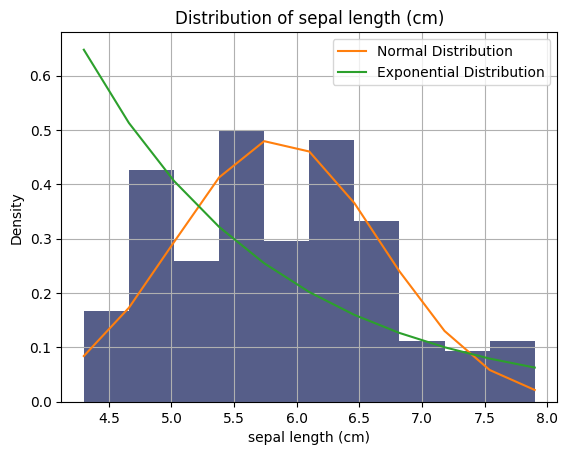

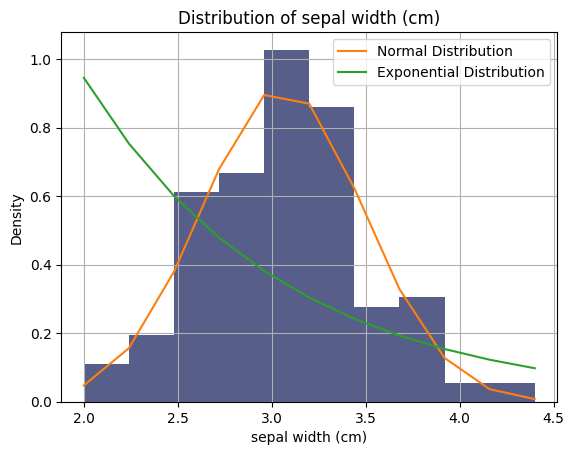

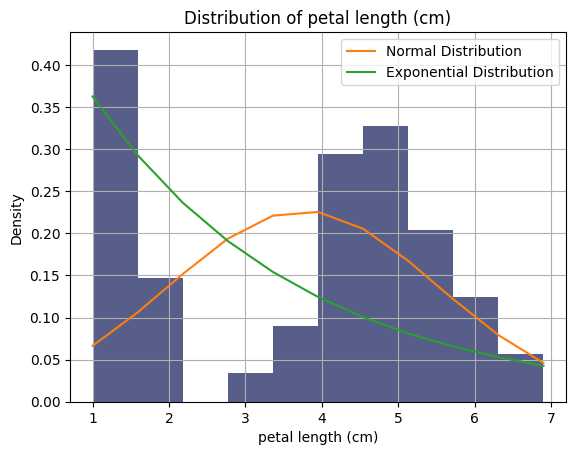

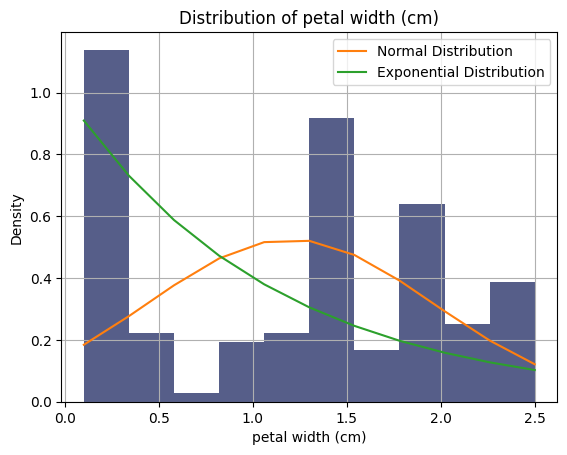

In [150]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

plot_distributions(X_iris)

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)


> We notice that all features follow a normal distribution (it is not always the case in real world applications).

In [151]:
class GaussianNaiveBayesClassifier:
    def __init__(self):
        self.priors = {}
        self.likelihoods = {}
        self.classes = []
        self.attributes = []
        self.n_attributes = 0

    def fit(self, X, y):
        # -------------------------------------------------------------------------
        # -------------------Step 1: Calculate Prior Probs-------------------------
        # -------------------------------------------------------------------------

        # Ensure X is a DataFrame and y is array-like with matching number of samples
        assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame."
        assert hasattr(y, '__len__'), "y must be an array-like object."
        assert len(X) == len(y), "Number of samples in X and y must be equal."

        self.classes, counts = np.unique(y, return_counts=True)  # TODO: Extract unique class labels and their counts from the target variable y.
        probabilities = counts / len(y)  # TODO: Compute prior probabilities for each class
        self.priors = dict(zip(self.classes, probabilities))  # TODO: Store prior probabilities in a dictionary where keys are class labels and values are probabilities.
        self.attributes = list(X.columns)  # TODO: Extract the list of feature names (column names) from the dataset X.
        self.n_attributes = len(self.attributes)  # TODO: Store the number of attributes to be used later in the model.

        # Ensure that there is at least one feature
        assert self.n_attributes > 0, "X must have at least one feature."

        """
        Likelihoods:
        {
            class_: {
                'means': np.array,
                'stds': np.array
            },
            ...
        }
        """
        # ----------------------------------------------------------------------------------------
        # -------------------Step 2: Estimate the Likelihoods-------------------------------------
        # ----------------------------------------------------------------------------------------

        for class_ in self.classes:
            self.likelihoods[class_] = {}
            conditional_distribution = X[y == class_]  # TODO: Extract all samples from X that belong to the current class.

            # Ensure there is at least one sample for the class
            assert len(conditional_distribution) > 0, f"No samples found for class {class_}."

            means = np.mean(conditional_distribution, axis=0)  # TODO: Compute the mean of each feature for the current class.
            stds = np.std(conditional_distribution, axis=0)  # TODO: Compute the standard deviation of each feature for the current class.


            # Ensure the computed means and stds match the number of attributes
            assert means.shape[0] == self.n_attributes, "Mismatch in number of attributes for means."
            assert stds.shape[0] == self.n_attributes, "Mismatch in number of attributes for stds."

            self.likelihoods[class_]["means"] = means
            self.likelihoods[class_]["stds"] = stds

    def predict(self, X):
        # Convert X to numpy array if it's a DataFrame, ensuring the same column order as training.
        if isinstance(X, pd.DataFrame):
            for attr in self.attributes:
                assert attr in X.columns, f"Missing attribute: {attr}"
            X = X[self.attributes].to_numpy()
        else:
            assert isinstance(X, np.ndarray), "X must be a pandas DataFrame or a numpy array."
            assert X.ndim == 2, "X must be a 2D array."
            assert X.shape[1] == self.n_attributes, "Number of features in X must match training data."

        return np.apply_along_axis(self.__predict, axis=1, arr=X)  # TODO: Fill in the missing arguments

    def __predict(self, x):
        # ----------------------------------------------------------------------------------------
        # -------------------Step 4: Calculate Posterior Probs------------------------------------
        # ----------------------------------------------------------------------------------------

        assert len(x) == self.n_attributes, "Input vector length does not match number of attributes."
        predictions = {class_: None for class_ in self.classes}

        # Iterate over each class to compute the probability of x belonging to that class.
        for class_ in self.classes:
            probabilities = self.__fill_probabilities(x, class_) # Calculate the likelihood of each feature given the class using Gaussian distribution.
            predictions[class_] = np.prod(probabilities) # TODO: Multiply all feature probabilities together to get the final posterior probability for the class.

            # Optionally, you can assert the probability is > 0:
            # assert predictions[class_] > 0, "Smoothing failed; probability is zero."

        return max(predictions.items(), key=lambda pair: pair[1])[0]

    def __fill_probabilities(self, x, class_):
        # ----------------------------------------------------------------------------------------
        # -------------------Step 3: Apply PDF-------------------------------------
        # -------------------------------------------------------------------------
        probabilities = np.zeros(self.n_attributes + 1)  # TODO: Initialize an array to store the probabilities of each feature and the prior probability.


        # Ensure the prior exists for the class
        assert class_ in self.priors, f"Prior for class {class_} not found."
        probabilities[-1] = self.priors[class_]

        means, stds = self.likelihoods[class_]["means"], self.likelihoods[class_]["stds"]
        # Add a small constant for numerical stability
        stds = stds + 1e-9 #(Smoothing)

        # Ensure that means and stds have the expected length
        assert means.shape[0] == len(x), "Mismatch between means and input vector length."
        assert stds.shape[0] == len(x), "Mismatch between stds and input vector length."

        probabilities[:-1] = self.__gaussian_fn(x, means, stds) # TODO: Apply the Gaussian Probability Density Function (PDF) to compute feature likelihoods.

        return probabilities

    def __gaussian_fn(self, x, means, stds):
        # TODO : Convert inputs to numpy arrays and assert matching shapes
        x = np.array(x)
        means = np.array(means)
        stds = np.array(stds)

        assert x.shape == means.shape == stds.shape, "x, means, and stds must have the same shape."

        return (1 / (stds * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x - means) ** 2 / (stds ** 2))

---
> The Gaussian Naive Bayes classifier is ready! Let’s test it against scikit-learn’s implementation to see how it performs
---

In [152]:

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Our Gaussian Naive Bayes classifier----------------------------------
#-----------------------------------------------------------------------------------------------------------

clf = GaussianNaiveBayesClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------scikit-learn Gaussian Naive Bayes classifier-------------------------
#-----------------------------------------------------------------------------------------------------------

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_sklearn = gnb.predict(X_test)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Compare the results--------------------------------------------------
#-----------------------------------------------------------------------------------------------------------
print("Custom GNB predictions:", y_pred)
print("Scikit-learn GNB predictions:", y_pred_sklearn)

assert np.array_equal(y_pred, y_pred_sklearn), "The predictions do not match!"
print("Test passed successfully! =D, Custom GNB predictions match scikit-learn GNB predictions.")

Custom GNB predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Scikit-learn GNB predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Test passed successfully! =D, Custom GNB predictions match scikit-learn GNB predictions.
